In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("plots", exist_ok=True)
np.random.seed(42)

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Liberation Serif', 'DejaVu Serif'],
    'font.size': 12,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'figure.facecolor': 'white',
    'savefig.facecolor': 'white',
})

In [2]:
# task1

# loading the Banknote Authentication dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"
cols = ['Variance', 'Skewness', 'Curtosis', 'Entropy', 'Class']
df = pd.read_csv(url, header=None, names=cols)

# displaying the first 5 samples
print("First five samples:")
print(df.head(), "\n")

# dataset dimensions
print("Dataset dimensions:", df.shape)
print("  Instances:", df.shape[0], "| Columns:", df.shape[1], "\n")

# missing values identification
print("Missing values per column:")
print(df.isnull().sum(), "\n")

# displaying descriptive statistics
print("Descriptive statistics:")
print(df.describe())

# class distribution
print("\nClass distribution:")
print(df['Class'].value_counts())

First five samples:
   Variance  Skewness  Curtosis  Entropy  Class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0 

Dataset dimensions: (1372, 5)
  Instances: 1372 | Columns: 5 

Missing values per column:
Variance    0
Skewness    0
Curtosis    0
Entropy     0
Class       0
dtype: int64 

Descriptive statistics:
          Variance     Skewness     Curtosis      Entropy        Class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.319650     0.616630    -0.586650     0.0

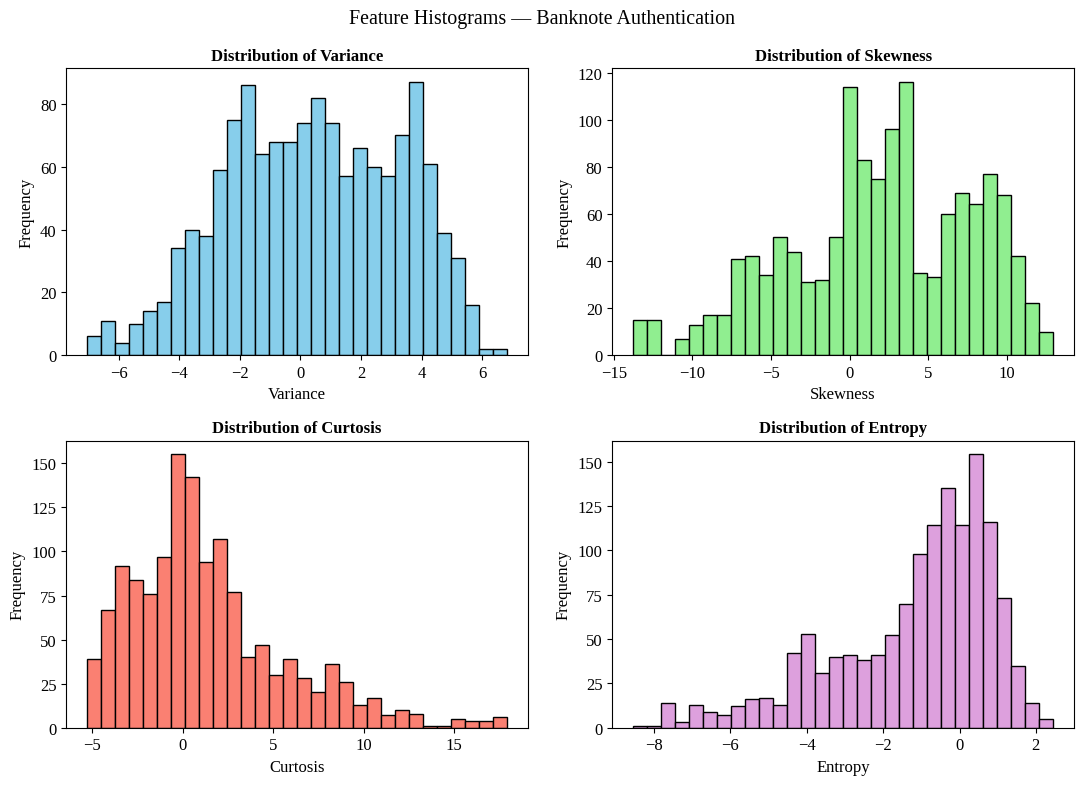

In [11]:
# task2 - histograms
features = ['Variance', 'Skewness', 'Curtosis', 'Entropy']
colors = ['skyblue', 'lightgreen', 'salmon', 'plum']

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

for ax, col, color in zip(axes.flat, features, colors):
    ax.hist(df[col], bins=30, color=color, edgecolor='black')
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.suptitle("Feature Histograms — Banknote Authentication")
plt.tight_layout()
plt.savefig("plots/hist_features.png", dpi=150, bbox_inches='tight')
plt.show()

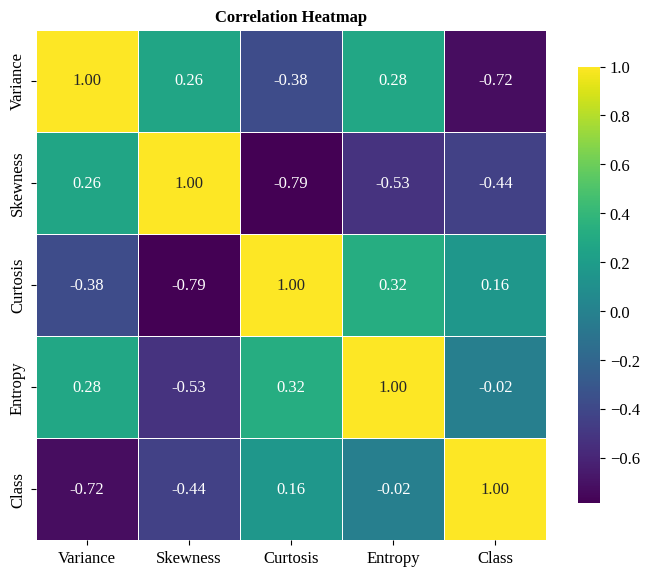

In [7]:
# task2 - correlation heatmap
plt.figure(figsize=(7, 6))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='viridis',
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("plots/correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

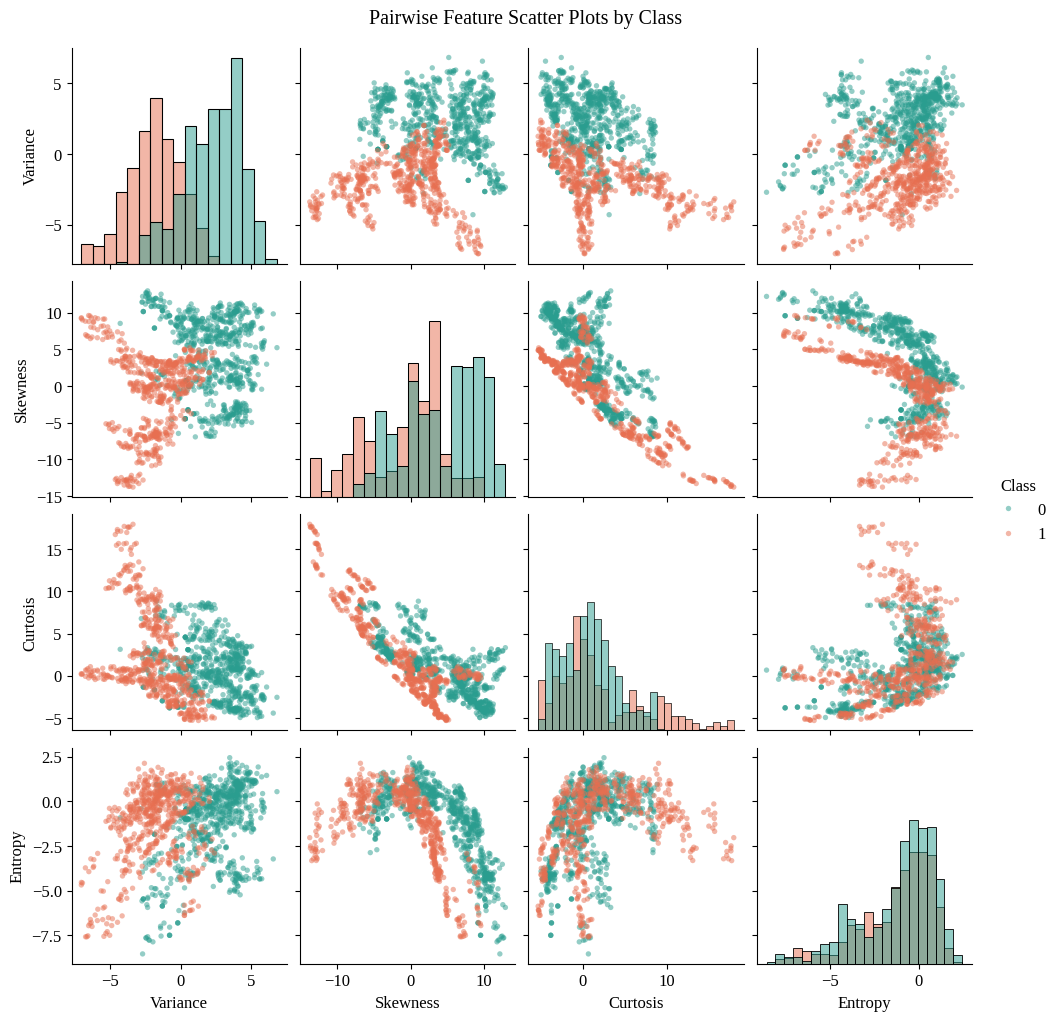

In [12]:
# task2 - pairwise scatter plots
pair = sns.pairplot(df, hue='Class', vars=features,
                    palette={0: '#2a9d8f', 1: '#e76f51'},
                    plot_kws={'alpha': 0.5, 's': 15, 'edgecolor': 'none'},
                    diag_kind='hist')
pair.fig.suptitle("Pairwise Feature Scatter Plots by Class", y=1.02)
pair.savefig("plots/pairplot_features.png", dpi=150, bbox_inches='tight')
plt.show()

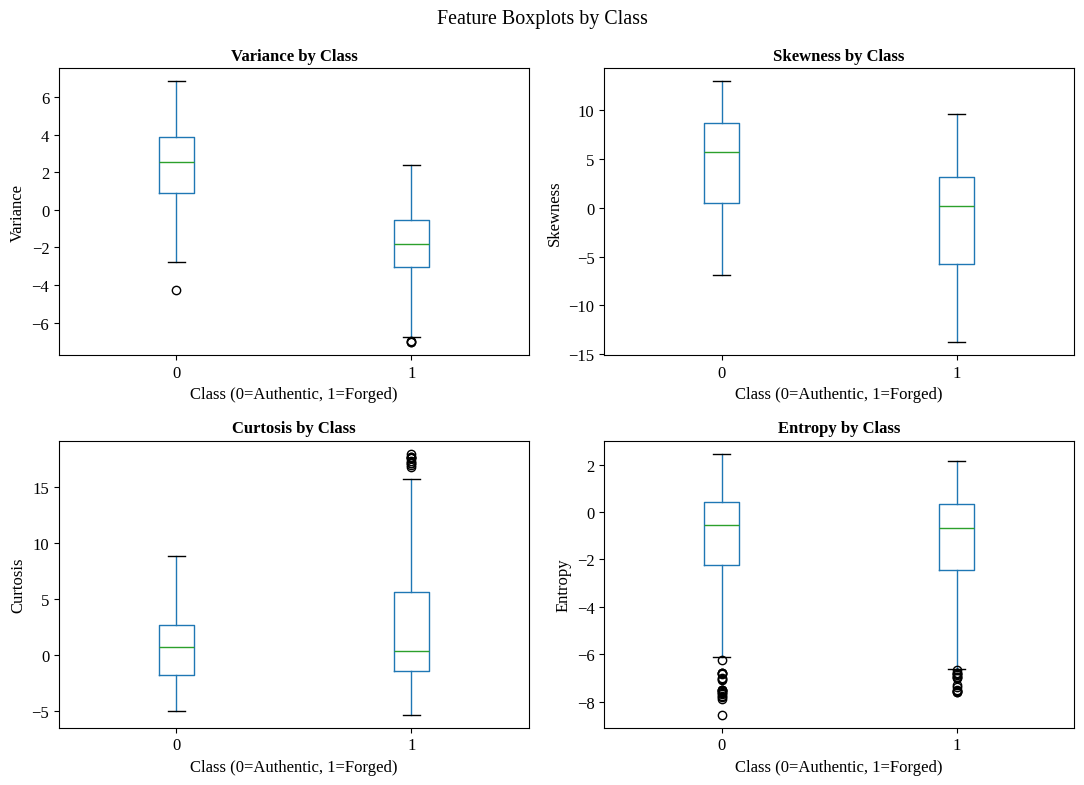

In [13]:
# task2 - boxplots
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.flat, features):
    df.boxplot(column=col, by='Class', ax=ax, grid=False)
    ax.set_title(f"{col} by Class")
    ax.set_xlabel("Class (0=Authentic, 1=Forged)"); ax.set_ylabel(col)
plt.suptitle("Feature Boxplots by Class")
plt.tight_layout()
plt.savefig("plots/boxplots_features.png", dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# task3

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df[features].values
y = df['Class'].values

# normalise all numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before normalization (first row):", X[0])
print("After normalization  (first row):", np.round(X_scaled[0], 4))
print("Feature means after scaling:", np.round(X_scaled.mean(axis=0), 4))
print("Feature stds after scaling :", np.round(X_scaled.std(axis=0), 4), "\n")

# split into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("Training set:", X_train.shape, "| Testing set:", X_test.shape)
print("Train class balance:", np.bincount(y_train))
print("Test class balance :", np.bincount(y_test))

Before normalization (first row): [ 3.6216   8.6661  -2.8073  -0.44699]
After normalization  (first row): [ 1.1218  1.1495 -0.976   0.3546]
Feature means after scaling: [ 0.  0.  0. -0.]
Feature stds after scaling : [1. 1. 1. 1.] 

Training set: (1097, 4) | Testing set: (275, 4)
Train class balance: [609 488]
Test class balance : [153 122]


In [15]:
# task4 - implementing Single Layer Perceptron from scratch

class Perceptron:
    def __init__(self, n_features, learning_rate=0.01, n_epochs=50):
        self.weights = np.zeros(n_features)

        self.bias = 0.0
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.history = []

    def step(self, z):
        # step activation function: 1 if z >= 0, else 0
        return np.where(z >= 0, 1, 0)

    def forward(self, x):
        # forward propagation: weighted sum + bias, then activation
        z = np.dot(x, self.weights) + self.bias
        return self.step(z)

    def fit(self, X, y):
        for epoch in range(self.n_epochs):
            errors = 0
            for xi, target in zip(X, y):
                # prediction for this sample
                y_pred = self.forward(xi)
                # Perceptron Learning Rule:
                #   w <- w + lr * (y - y_pred) * x
                #   b <- b + lr * (y - y_pred)
                update = self.lr * (target - y_pred)
                if update != 0:
                    self.weights += update * xi
                    self.bias += update
                    errors += 1
            # record state at end of each epoch
            self.history.append((epoch + 1, errors,
                                 self.weights.copy(), self.bias))
            if errors == 0:
                print(f"Converged at epoch {epoch + 1}")
                break
        return self

    def predict(self, X):
        return self.forward(X)

print("Perceptron class defined.")

Perceptron class defined.


In [16]:
# task5

model = Perceptron(n_features=X_train.shape[1], learning_rate=0.01, n_epochs=50)

print(f"{'Epoch':<7}{'Misclassified':<15}{'Weights':<45}{'Bias':<10}")
print("-" * 77)

for epoch in range(model.n_epochs):
    errors = 0
    for xi, target in zip(X_train, y_train):
        y_pred = model.forward(xi)
        update = model.lr * (target - y_pred)
        if update != 0:
            model.weights += update * xi
            model.bias += update
            errors += 1
    model.history.append((epoch + 1, errors, model.weights.copy(), model.bias))

    # displaying epoch number, misclassified count, updated weights, updated bias
    print(f"{epoch+1:<7}{errors:<15}{str(np.round(model.weights, 4)):<45}{model.bias:<10.4f}")

    if errors == 0:
        print("-" * 77)
        print(f"Converged at epoch {epoch+1} — no misclassifications.")
        break

Epoch  Misclassified  Weights                                      Bias      
-----------------------------------------------------------------------------
1      59             [-0.068  -0.0938 -0.0678 -0.011 ]            -0.0300   
2      25             [-0.0775 -0.1042 -0.0811  0.0035]            -0.0400   
3      20             [-0.0802 -0.1127 -0.0917 -0.0036]            -0.0400   
4      19             [-0.0883 -0.1196 -0.1001  0.0089]            -0.0500   
5      20             [-0.0991 -0.1295 -0.1037  0.0102]            -0.0500   
6      17             [-0.1027 -0.1277 -0.1134 -0.001 ]            -0.0600   
7      24             [-0.1081 -0.1393 -0.1108 -0.0094]            -0.0600   
8      22             [-0.117  -0.1357 -0.1319 -0.0025]            -0.0600   
9      20             [-0.1176 -0.147  -0.1364 -0.0062]            -0.0600   
10     20             [-0.1307 -0.1541 -0.125  -0.006 ]            -0.0600   
11     22             [-0.1345 -0.1641 -0.1329 -0.0018]         

In [17]:
# task6

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

y_pred_test = model.predict(X_test)

accuracy  = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test)
recall    = recall_score(y_test, y_pred_test)
f1        = f1_score(y_test, y_pred_test)

print("===== PERCEPTRON EVALUATION (Test Set) =====")
print(f"  Accuracy : {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall   : {recall:.4f}")
print(f"  F1-score : {f1:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_test,
                            target_names=['Authentic (0)', 'Forged (1)'], digits=4))

===== PERCEPTRON EVALUATION (Test Set) =====
  Accuracy : 0.9855
  Precision: 0.9683
  Recall   : 1.0000
  F1-score : 0.9839

Classification Report:
               precision    recall  f1-score   support

Authentic (0)     1.0000    0.9739    0.9868       153
   Forged (1)     0.9683    1.0000    0.9839       122

     accuracy                         0.9855       275
    macro avg     0.9841    0.9869    0.9853       275
 weighted avg     0.9859    0.9855    0.9855       275



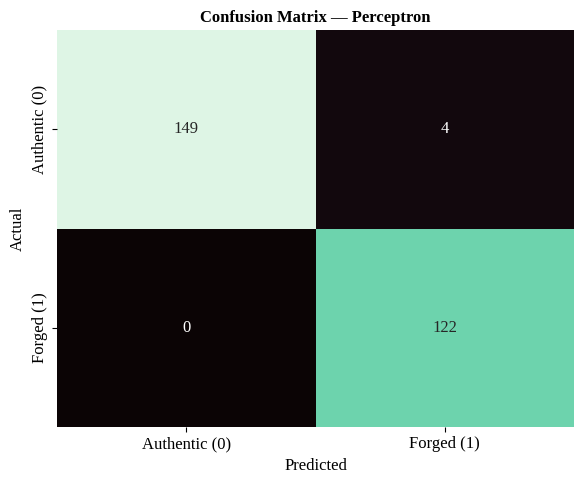

True Negatives : 149  (authentic correctly identified)
False Positives: 4  (authentic wrongly flagged as forged)
False Negatives: 0  (forged wrongly passed as authentic)
True Positives : 122  (forged correctly caught)


In [20]:
# task6 - confusion matrix

cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='mako', cbar=False,
            xticklabels=['Authentic (0)', 'Forged (1)'],
            yticklabels=['Authentic (0)', 'Forged (1)'])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix — Perceptron")
plt.tight_layout()
plt.savefig("plots/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives : {tn}  (authentic correctly identified)")
print(f"False Positives: {fp}  (authentic wrongly flagged as forged)")
print(f"False Negatives: {fn}  (forged wrongly passed as authentic)")
print(f"True Positives : {tp}  (forged correctly caught)")

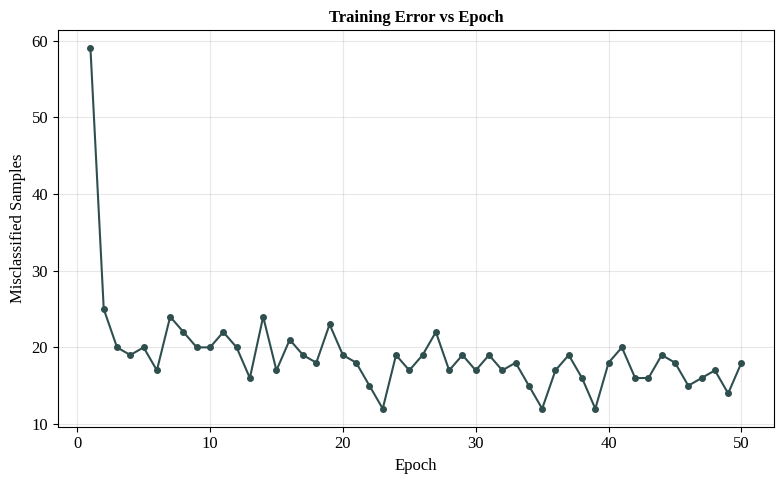

In [23]:
# plot - training error vs. epoch
epochs   = [h[0] for h in model.history]
errors   = [h[1] for h in model.history]

plt.figure(figsize=(8, 5))
plt.plot(epochs, errors, marker='o', ms=4, color='#2F4F4F')
plt.xlabel("Epoch"); plt.ylabel("Misclassified Samples")
plt.title("Training Error vs Epoch")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("plots/training_error.png", dpi=150, bbox_inches='tight')
plt.show()

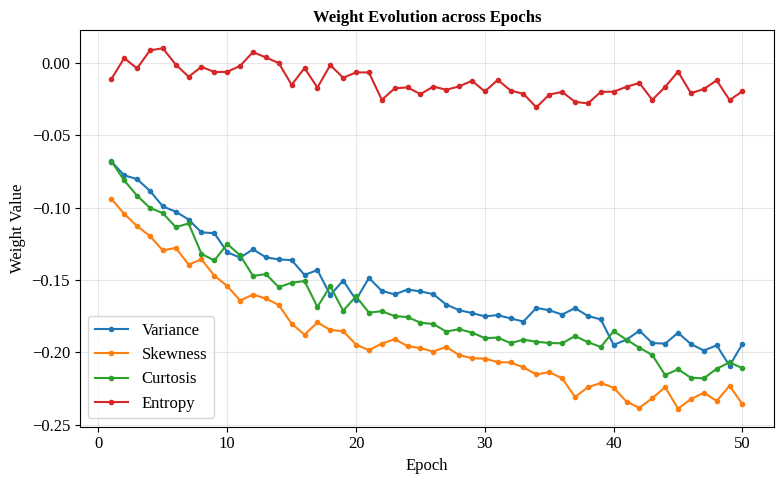

In [24]:
# 7 - weight evolution across epochs
weights_over_time = np.array([h[2] for h in model.history])

plt.figure(figsize=(8, 5))
for i, name in enumerate(features):
    plt.plot(epochs, weights_over_time[:, i], marker='o', ms=3, label=name)
plt.xlabel("Epoch"); plt.ylabel("Weight Value")
plt.title("Weight Evolution across Epochs")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("plots/weight_evolution.png", dpi=150, bbox_inches='tight')
plt.show()

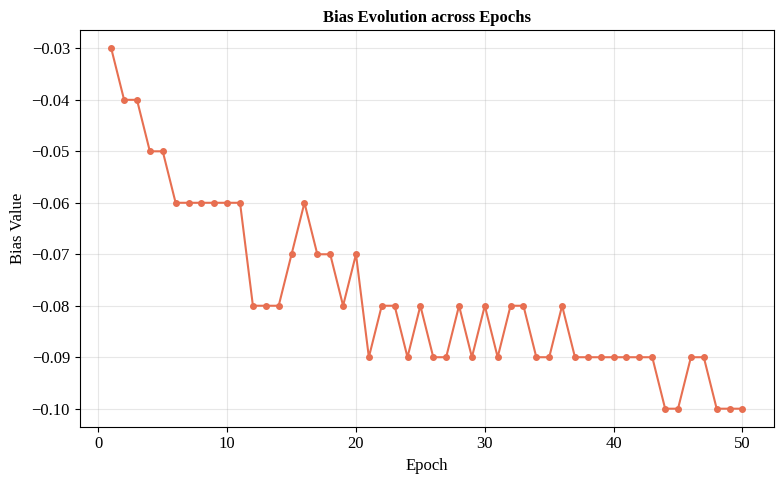

In [25]:
# 7 - bias evolution across epochs
bias_over_time = [h[3] for h in model.history]

plt.figure(figsize=(8, 5))
plt.plot(epochs, bias_over_time, marker='o', ms=4, color='#e76f51')
plt.xlabel("Epoch"); plt.ylabel("Bias Value")
plt.title("Bias Evolution across Epochs")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("plots/bias_evolution.png", dpi=150, bbox_inches='tight')
plt.show()

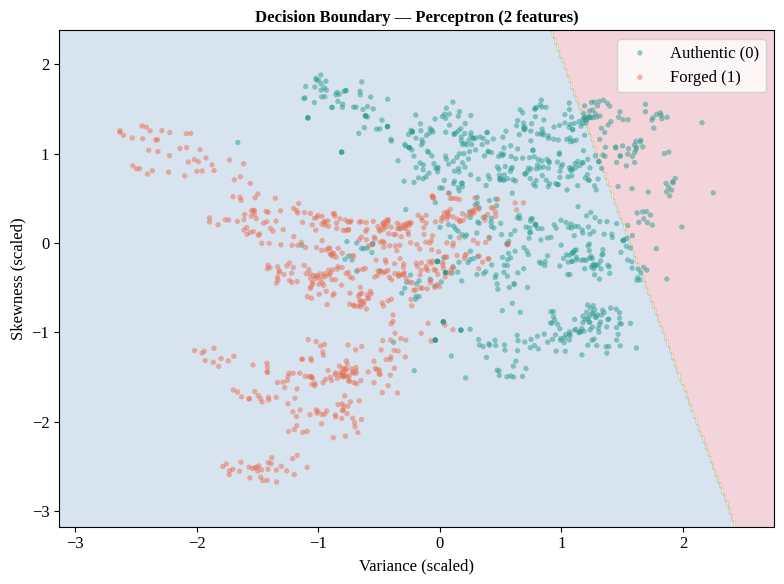

In [28]:
# 7 - decision boundary using 2 features (variance and skewness)
from sklearn.preprocessing import StandardScaler

# Retrain a perceptron on just the two chosen features for a 2D boundary
idx = [0, 1]  # Variance, Skewness
X2 = StandardScaler().fit_transform(df[[features[0], features[1]]].values)
m2 = Perceptron(n_features=2, learning_rate=0.01, n_epochs=50).fit(X2, y)

# Mesh grid over the two features
x_min, x_max = X2[:, 0].min() - 0.5, X2[:, 0].max() + 0.5
y_min, y_max = X2[:, 1].min() - 0.5, X2[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
Z = m2.forward(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.2, cmap='Spectral')
for cls, colour, label in [(0, '#2a9d8f', 'Authentic (0)'), (1, '#e76f51', 'Forged (1)')]:
    pts = X2[y == cls]
    plt.scatter(pts[:, 0], pts[:, 1], c=colour, label=label,
                alpha=0.5, edgecolors='none', s=15)
plt.xlabel("Variance (scaled)"); plt.ylabel("Skewness (scaled)")
plt.title("Decision Boundary — Perceptron (2 features)")
plt.legend(); plt.tight_layout()
plt.savefig("plots/decision_boundary.png", dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# Additional Task: Repeat the experiment at learning rates 0.001, 0.01, 0.1
from sklearn.metrics import accuracy_score

learning_rates = [0.001, 0.01, 0.1]
results = []

for lr in learning_rates:
    m = Perceptron(n_features=X_train.shape[1], learning_rate=lr, n_epochs=50)

    converged_epoch = None
    for epoch in range(m.n_epochs):
        errors = 0
        for xi, target in zip(X_train, y_train):
            y_pred = m.forward(xi)
            update = m.lr * (target - y_pred)
            if update != 0:
                m.weights += update * xi
                m.bias += update
                errors += 1
        if errors == 0 and converged_epoch is None:
            converged_epoch = epoch + 1
            break

    # evaluate on test set
    test_acc = accuracy_score(y_test, m.predict(X_test))
    results.append({
        'Learning Rate': lr,
        'Converged Epoch': converged_epoch if converged_epoch else 'Did not converge',
        'Test Accuracy': round(test_acc, 4),
        'Final Weights': np.round(m.weights, 3),
        'Final Bias': round(m.bias, 4),
    })

# Display as a comparison table
print(f"{'LR':<8}{'Conv. Epoch':<16}{'Test Acc':<12}{'Final Bias':<12}")
print("-" * 48)
for r in results:
    print(f"{r['Learning Rate']:<8}{str(r['Converged Epoch']):<16}"
          f"{r['Test Accuracy']:<12}{r['Final Bias']:<12}")

print("\nFinal weights per learning rate:")
for r in results:
    print(f"  lr={r['Learning Rate']}: {r['Final Weights']}")

LR      Conv. Epoch     Test Acc    Final Bias  
------------------------------------------------
0.001   Did not converge0.9855      -0.01       
0.01    Did not converge0.9855      -0.1        
0.1     Did not converge0.9855      -1.0        

Final weights per learning rate:
  lr=0.001: [-0.019 -0.024 -0.021 -0.002]
  lr=0.01: [-0.194 -0.236 -0.211 -0.019]
  lr=0.1: [-1.941 -2.358 -2.109 -0.195]


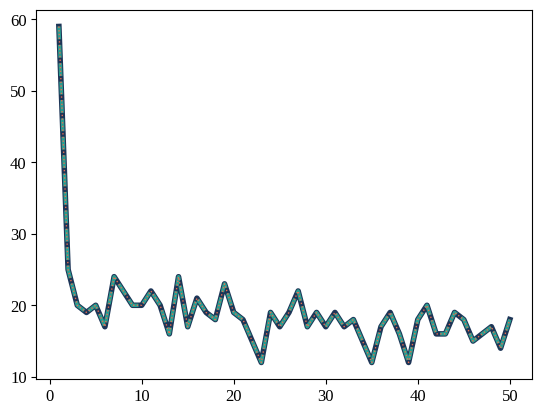

In [38]:
# learning rate comparision plot
styles = ['-', '--', ':']
widths = [4, 2.5, 1]
for lr, colour, ls, lw in zip(learning_rates, colours, styles, widths):
    m = Perceptron(n_features=X_train.shape[1], learning_rate=lr, n_epochs=50)
    err_curve = []
    for epoch in range(m.n_epochs):
        errors_e = 0
        for xi, target in zip(X_train, y_train):
            y_pred = m.forward(xi)
            update = m.lr * (target - y_pred)
            if update != 0:
                m.weights += update * xi
                m.bias += update
                errors_e += 1
        err_curve.append(errors_e)
    plt.plot(range(1, len(err_curve)+1), err_curve,
             color=colour, linestyle=ls, linewidth=lw, label=f"lr = {lr}")

In [34]:
# additional task - compare with Scikit-learn's Perceptron

from sklearn.linear_model import Perceptron as SklearnPerceptron
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

sk = SklearnPerceptron(max_iter=50, eta0=0.01, random_state=42)
sk.fit(X_train, y_train)
sk_pred = sk.predict(X_test)

print("===== Scikit-learn Perceptron =====")
print(f"  Accuracy : {accuracy_score(y_test, sk_pred):.4f}")
print(f"  Precision: {precision_score(y_test, sk_pred):.4f}")
print(f"  Recall   : {recall_score(y_test, sk_pred):.4f}")
print(f"  F1-score : {f1_score(y_test, sk_pred):.4f}")

===== Scikit-learn Perceptron =====
  Accuracy : 0.9745
  Precision: 0.9457
  Recall   : 1.0000
  F1-score : 0.9721



===== OR gate =====
Initial weights: [0. 0. 0.]
  update 1: input [0. 0.], target 0, pred 1 -> weights [-0.1  0.   0. ]


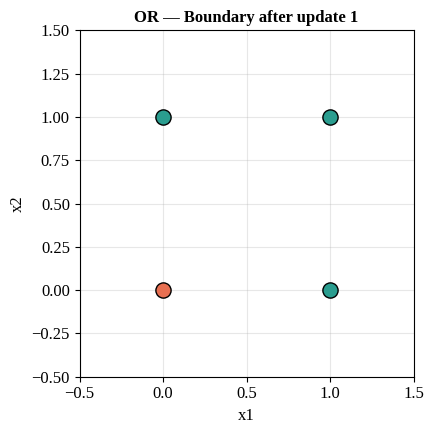

  update 2: input [0. 1.], target 1, pred 0 -> weights [0.  0.  0.1]


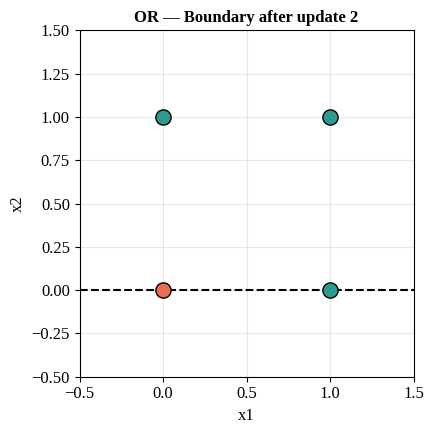

  update 3: input [0. 0.], target 0, pred 1 -> weights [-0.1  0.   0.1]


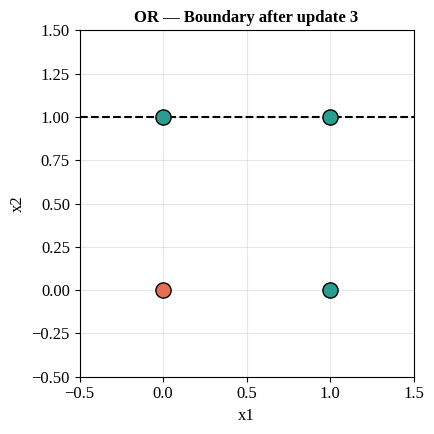

  update 4: input [1. 0.], target 1, pred 0 -> weights [0.  0.1 0.1]


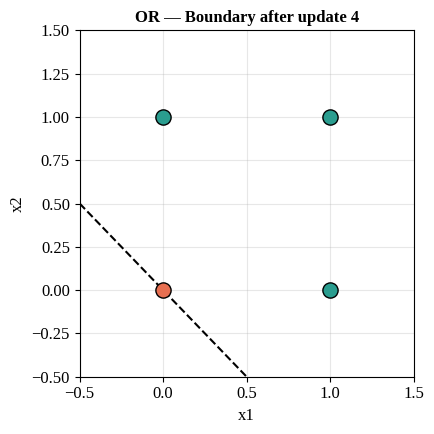

  update 5: input [0. 0.], target 0, pred 1 -> weights [-0.1  0.1  0.1]


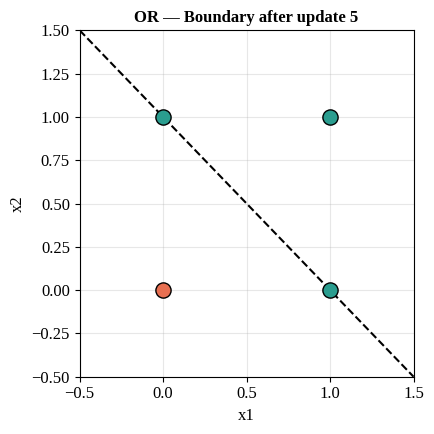

  Converged after epoch 4

===== AND gate =====
Initial weights: [0. 0. 0.]
  update 1: input [0. 0.], target 0, pred 1 -> weights [-0.1  0.   0. ]


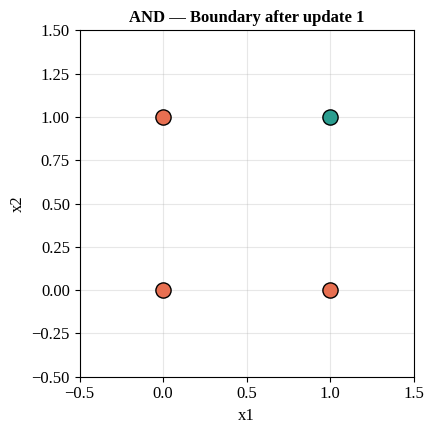

  update 2: input [1. 1.], target 1, pred 0 -> weights [0.  0.1 0.1]


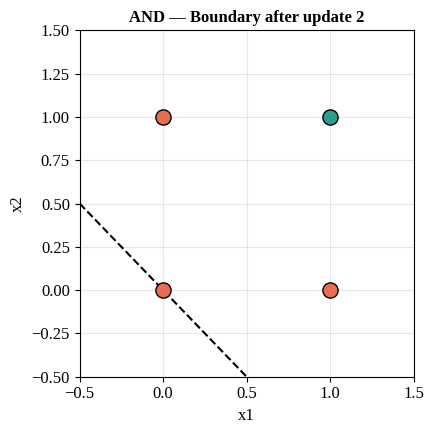

  update 3: input [0. 0.], target 0, pred 1 -> weights [-0.1  0.1  0.1]


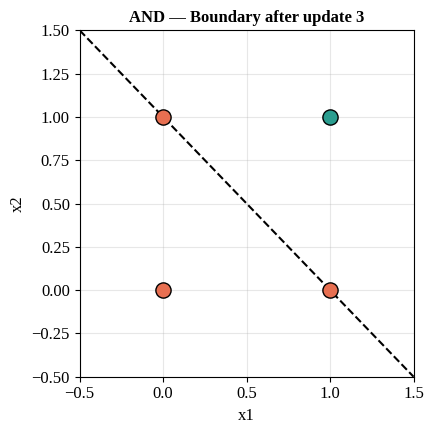

  update 4: input [0. 1.], target 0, pred 1 -> weights [-0.2  0.1  0. ]


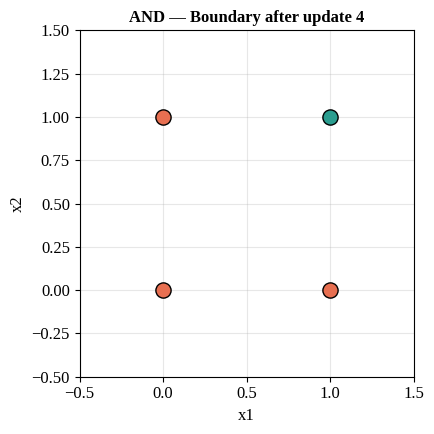

  update 5: input [1. 1.], target 1, pred 0 -> weights [-0.1  0.2  0.1]


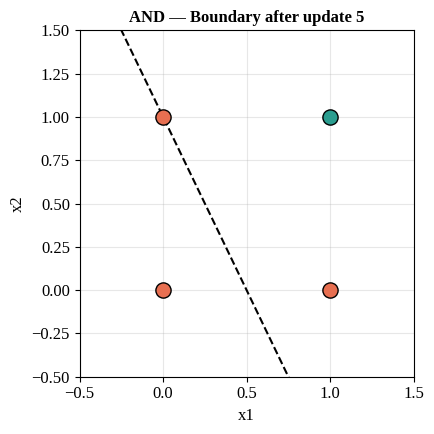

  update 6: input [0. 1.], target 0, pred 1 -> weights [-0.2  0.2  0. ]


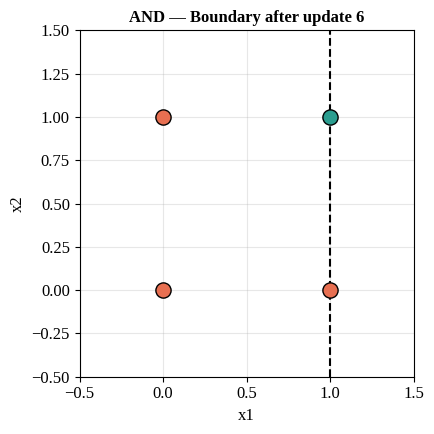

  update 7: input [1. 0.], target 0, pred 1 -> weights [-0.3  0.1  0. ]


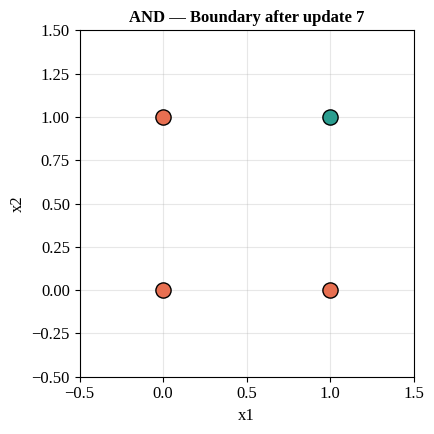

  update 8: input [1. 1.], target 1, pred 0 -> weights [-0.2  0.2  0.1]


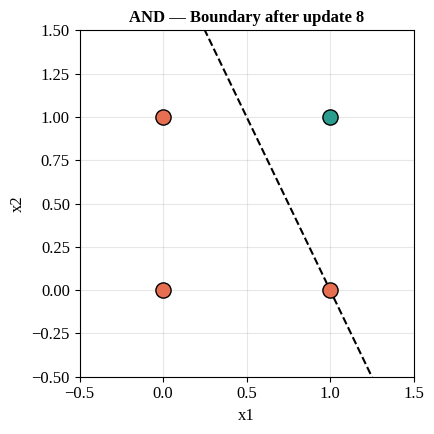

  Converged after epoch 4

===== NOT gate =====
Initial weights: [0. 0. 0.]
  update 1: input [1. 0.], target 0, pred 1 -> weights [-0.1 -0.1  0. ]


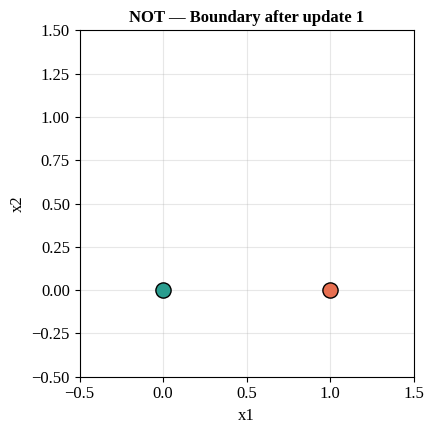

  update 2: input [0. 0.], target 1, pred 0 -> weights [ 0.  -0.1  0. ]


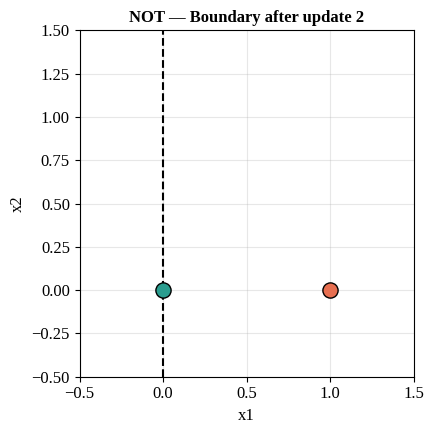

  Converged after epoch 3


array([ 0. , -0.1,  0. ])

In [39]:
# additional task: Perceptron for OR, NOT, and AND gates

import os; os.makedirs("plots", exist_ok=True)
import numpy as np
import matplotlib.pyplot as plt

def train_gate(X, y, gate_name, lr=0.1, epochs=10):
    Xb = np.c_[np.ones(len(X)), X]          # bias absorbed as w[0]
    w = np.zeros(Xb.shape[1])
    print(f"\n===== {gate_name} gate =====")
    print(f"Initial weights: {w}")

    update_no = 0
    for epoch in range(epochs):
        errors = 0
        for xi, target in zip(Xb, y):
            pred = 1 if np.dot(w, xi) >= 0 else 0
            delta = lr * (target - pred)
            if delta != 0:
                w = w + delta * xi
                errors += 1
                update_no += 1
                print(f"  update {update_no}: input {xi[1:]}, target {target}, "
                      f"pred {pred} -> weights {np.round(w, 3)}")
                plot_boundary(X, y, w, gate_name, update_no)
        if errors == 0:
            print(f"  Converged after epoch {epoch+1}")
            break
    return w

def plot_boundary(X, y, w, gate_name, update_no):
    plt.figure(figsize=(4.5, 4.5))
    for xi, target in zip(X, y):
        plt.scatter(*xi, c='#2a9d8f' if target == 1 else '#e76f51',
                    s=120, edgecolors='black', zorder=3)
    # decision line: w0 + w1*x1 + w2*x2 = 0
    if abs(w[2]) > 1e-6:
        xs = np.linspace(-0.5, 1.5, 100)
        plt.plot(xs, -(w[0] + w[1]*xs)/w[2], 'k--')
    elif abs(w[1]) > 1e-6:
        plt.axvline(-w[0]/w[1], color='k', linestyle='--')
    plt.xlim(-0.5, 1.5); plt.ylim(-0.5, 1.5)
    plt.xlabel("x1"); plt.ylabel("x2")
    plt.title(f"{gate_name} — Boundary after update {update_no}")
    plt.grid(alpha=0.3); plt.tight_layout()
    plt.savefig(f"plots/gate_{gate_name.lower()}_update_{update_no:02d}.png",
                dpi=150, bbox_inches='tight')
    plt.show()

# OR gate
X_or  = np.array([[0,0],[0,1],[1,0],[1,1]]); y_or  = np.array([0,1,1,1])
train_gate(X_or, y_or, "OR")

# AND gate
X_and = np.array([[0,0],[0,1],[1,0],[1,1]]); y_and = np.array([0,0,0,1])
train_gate(X_and, y_and, "AND")

# NOT gate (single input; x2 padded with 0 so the 2D plotter works)
X_not = np.array([[0,0],[1,0]]); y_not = np.array([1,0])
train_gate(X_not, y_not, "NOT")

In [40]:
!zip -qr plots.zip plots
from google.colab import files
files.download("plots.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>